In [ ]:
import numpy as np
import pandas as pd

In [ ]:
true_df = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')

In [ ]:
display(true_df.head())
print(true_df.info())

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    405 non-null    object
 1   text     405 non-null    object
 2   subject  405 non-null    object
 3   date     405 non-null    object
dtypes: object(4)
memory usage: 12.8+ KB
None


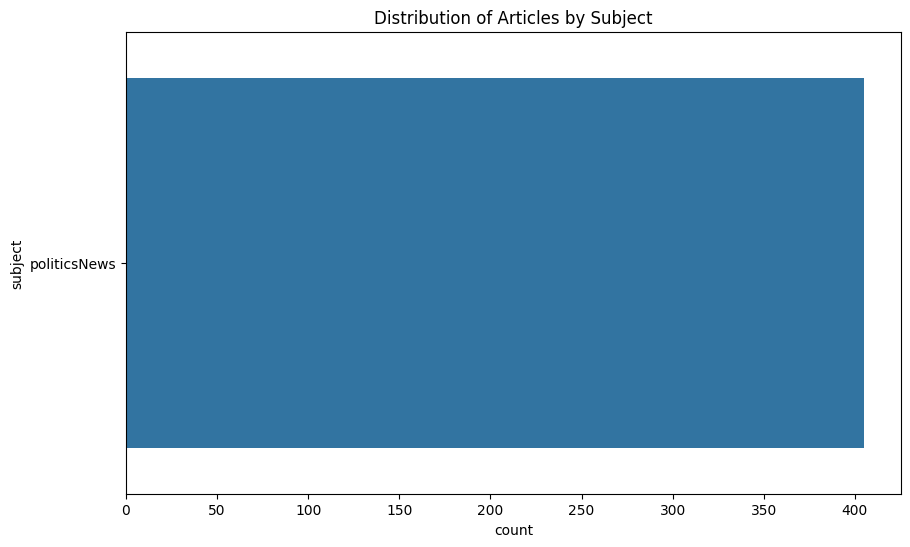

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(y='subject', data=true_df)
plt.title('Distribution of Articles by Subject')
plt.show()

In [ ]:
fake_df = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')
display(fake_df.head())

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true_df['label'] = 1
fake_df['label'] = 0

data = pd.concat([true_df, fake_df])
data = data.sample(frac=1).reset_index(drop=True)

display(data.head())
print(data.info())

,title,text,subject,date,label
0,BREAKING: Someone Else Connected To Trump Is ...,"Today, more bad news for Trump broke as yet an...",News,"September 13, 2017",0
1,"Senator Franken, facing resignation calls, to ...",(Reuters) - U.S Democratic Senator Al Franken ...,politicsNews,"December 6, 2017",1
2,WATCH: Paul Ryan Just Told Us He Doesn’t Care...,Republicans are working overtime trying to sel...,News,"December 21, 2017",0
3,Conservative ‘Christian’ Leader Kept A Sexual...,Conservatives should shun Tony Perkins for thi...,News,"November 18, 2017",0
4,SURPRISE: The People Behind ‘Fearless Girl’ S...,There were a lot of arguments online after the...,News,"October 6, 2017",0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808 entries, 0 to 807
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    808 non-null    object
 1   text     808 non-null    object
 2   subject  808 non-null    object
 3   date     808 non-null    object
 4   label    808 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 31.7+ KB
None


In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)           # remove punctuation/numbers
    words = text.split()                             # split into words
    words = [stemmer.stem(word) for word in words if word not in stop_words]  # remove stopwords + stem
    return ' '.join(words)


In [ ]:
data['clean_title'] = data['title'].apply(clean_text)
data[['title', 'clean_title', 'label']].head()


,title,clean_title,label
0,BREAKING: Someone Else Connected To Trump Is ...,break someon els connect trump investig collud...,0
1,"Senator Franken, facing resignation calls, to ...",senat franken face resign call make announc th...,1
2,WATCH: Paul Ryan Just Told Us He Doesn’t Care...,watch paul ryan told us care struggl famili li...,0
3,Conservative ‘Christian’ Leader Kept A Sexual...,conserv christian leader kept sexual assault s...,0
4,SURPRISE: The People Behind ‘Fearless Girl’ S...,surpris peopl behind fearless girl statu cynic...,0


In [ ]:
from sklearn.model_selection import train_test_split

X = data['clean_title']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Train shape: (646, 1849)
Test shape: (162, 1849)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_tfidf)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8950617283950617

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89        79
           1       0.91      0.88      0.90        83

    accuracy                           0.90       162
   macro avg       0.90      0.90      0.90       162
weighted avg       0.90      0.90      0.90       162



In [ ]:
!pip install langdetect translate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a2b5a2d191e7bc8f93fd6e0370aab4517cde39462b335127a5222c5e4f4fb76a
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
from langdetect import detect
from translate import Translator


In [ ]:
def predict_news(text):
    try:
        lang = detect(text)
        if lang == 'hi':
            translator = Translator(from_lang="hi", to_lang="en")
            text = translator.translate(text)
    except:
        pass

    # Clean the text
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]

    return "Real News" if prediction == 1 else "Fake News"



In [ ]:
print(predict_news("This is the official government website of India."))
print(predict_news("यह खबर बिल्कुल सही है और सरकार द्वारा जारी की गई है।"))
print(predict_news("NASA confirms aliens are real and living in Canada!"))

Real News
Fake News
Fake News
